## Loading packages

In [6]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import psutil

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Loading the dataset

In [2]:
try:
    base = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base = os.getcwd()

path = os.path.join(base, 'KoTaP_Dataset (1).csv')
df = pd.read_csv(path, encoding='cp949')
print(df.shape)
df.head()


(12653, 65)


,name,stock,year,KOSPI,fnd_year,fiscal,ind,big4,forn,own,...,GETR5,CETR5,TSTA,TSDA,A_GETR,A_CETR,A_GETR3,A_CETR3,A_GETR5,A_CETR5
0,동화약품,20,2013,1,1897,12,21,1,0.0613,0.3114,...,0.294414,0.266121,-0.071863,-0.088363,-0.236479,0.748503,0.058765,-0.096756,0.034497,-0.019779
1,동화약품,20,2014,1,1897,12,21,1,0.0502,0.3151,...,0.233461,0.418783,-0.001226,-0.014614,-0.150710,0.748503,0.500993,0.733432,-0.026455,0.132883
2,동화약품,20,2015,1,1897,12,21,1,0.0749,0.3235,...,0.231593,0.528209,0.072994,0.056283,-0.171420,-0.024525,-0.195255,0.733432,-0.028324,0.242310
3,동화약품,20,2016,1,1897,12,21,1,0.0746,0.3229,...,0.306044,0.325968,0.106756,0.107570,0.026917,-0.194237,-0.174602,0.327249,0.046128,0.040069
4,동화약품,20,2017,1,1897,12,21,1,0.1186,0.3240,...,0.250474,0.216419,-0.061506,0.008744,0.042469,-0.157749,-0.014648,-0.184860,-0.009442,-0.069481


## Label and Split

In [3]:

df['label_cetr']  = (df['CETR']  <= df['CETR'].quantile(0.25)).astype(int)
df['label_getr']  = (df['GETR']  <= df['GETR'].quantile(0.25)).astype(int)
df['label_cetr3'] = (df['CETR3'] <= df['CETR3'].quantile(0.25)).astype(int)
df['label_getr3'] = (df['GETR3'] <= df['GETR3'].quantile(0.25)).astype(int)
df['label_cetr5'] = (df['CETR3'] <= df['CETR5'].quantile(0.25)).astype(int)
df['label_getr5'] = (df['GETR3'] <= df['GETR5'].quantile(0.25)).astype(int)

df['label_tsta'] = (df['TSTA'] >= df['TSTA'].quantile(0.75)).astype(int)
df['label_tsda'] = (df['TSDA'] >= df['TSDA'].quantile(0.75)).astype(int)


train=df[df['year']<=2019]
test=df[df['year']>=2020]
num=['ROA','ROE','CFO','LOSS_lag1','LEV','CUR', 'SIZE', 'PPE', 'AGE', 'INVREC', 'GRW', 'MB', 'TQ', 'KOSPI', 'big4', 'forn', 'own']
cat=['ind']

## RQ1 Feature Selection

In [4]:

sel=VarianceThreshold(1e-4).fit(train[num])
num_rq1=[c for c,k in zip(num, sel.get_support()) if k]
corr=train[num_rq1].corr().abs()

upper=corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop=[col for col in upper.columns if any(upper[col]>0.9)]
num_rq1=[c for c in num_rq1 if c not in drop]
sel2=SelectKBest(mutual_info_classif,k='all').fit(train[num_rq1],train['label_cetr'])
num_rq1=[c for c,k in zip(num_rq1, sel2.get_support()) if k]
print('RQ1 Features:', num_rq1)

RQ1 Features: ['ROA', 'CFO', 'LOSS_lag1', 'LEV', 'CUR', 'SIZE', 'PPE', 'AGE', 'INVREC', 'GRW', 'MB', 'KOSPI', 'big4', 'forn', 'own']


## RQ1 Models

In [7]:
process = psutil.Process(os.getpid())

labels = {
    'CETR'  : 'label_cetr',
    'GETR'  : 'label_getr',
    'CETR3' : 'label_cetr3',
    'GETR3' : 'label_getr3',
    'CETR5' : 'label_cetr5',
    'GETR5' : 'label_getr5',
    'TSTA'  : 'label_tsta',
    'TSDA'  : 'label_tsda'
}

for label_name, label_col in labels.items():

    print("\n" + "="*60)
    print(f"RQ1 Results using label: {label_name}")
    print("="*60)

    # Targets
    y_train = train[label_col]
    y_test  = test[label_col]

    # Features
    X_train = train[num_rq1 + cat]
    X_test  = test[num_rq1 + cat]

    # Preprocessing
    pre = ColumnTransformer([
        ('num',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('sc', StandardScaler())
         ]),
         num_rq1),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
    ])

    # Models
    models = {
        'Logistic (baseline)': LogisticRegression(max_iter=500),
        'Logistic (class-weighted)': LogisticRegression(
            max_iter=500,
            class_weight='balanced'
        ),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }

    for model_name, clf in models.items():

        pipe = Pipeline([
            ('prep', pre),
            ('clf', clf)
        ])

        # -------- Efficiency measurement --------
        mem_before = process.memory_info().rss / 1024**2  # MB
        start_fit = time.time()
        pipe.fit(X_train, y_train)
        fit_time = time.time() - start_fit
        mem_after = process.memory_info().rss / 1024**2   # MB

        start_pred = time.time()
        preds = pipe.predict(X_test)
        pred_time = time.time() - start_pred
        # ----------------------------------------

        print(f"\nModel: {model_name}")
        print("Accuracy:", accuracy_score(y_test, preds))
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, preds))
        print("Classification Report:")
        print(classification_report(y_test, preds, zero_division=0))

        print(f"Training time (s): {fit_time:.4f}")
        print(f"Prediction time (s): {pred_time:.4f}")
        print(f"Memory increase (MB): {mem_after - mem_before:.2f}")

        # -------- Model complexity proxies --------
        if 'Logistic' in model_name:
            n_features = pipe.named_steps['prep'].get_feature_names_out().shape[0]
            print("Number of features used:", n_features)

        if model_name == 'KNN':
            print("Training observations:", X_train.shape[0])
            print("k (neighbors):", clf.n_neighbors)


RQ1 Results using label: CETR

Model: Logistic (baseline)
Accuracy: 0.7295193617435298
Confusion Matrix:
[[3547  111]
 [1279  202]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.97      0.84      3658
           1       0.65      0.14      0.23      1481

    accuracy                           0.73      5139
   macro avg       0.69      0.55      0.53      5139
weighted avg       0.71      0.73      0.66      5139

Training time (s): 0.0389
Prediction time (s): 0.0061
Memory increase (MB): 5.33
Number of features used: 61

Model: Logistic (class-weighted)
Accuracy: 0.6656937147304923
Confusion Matrix:
[[2529 1129]
 [ 589  892]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.69      0.75      3658
           1       0.44      0.60      0.51      1481

    accuracy                           0.67      5139
   macro avg       0.63      0.65      0.63      5139
weigh

In [8]:


# ------------------------------------
# Labels to validate (representative)
# ------------------------------------
ts_labels = {
    'CETR'  : 'label_cetr',
    'CETR3' : 'label_cetr3',
    'TSDA'  : 'label_tsda'
}

# ------------------------------------
# Models to validate
# ------------------------------------
models = {
    'Logistic (baseline)': LogisticRegression(max_iter=500),
    'Logistic (class-weighted)': LogisticRegression(
        max_iter=500,
        class_weight='balanced'
    )
}

# ------------------------------------
# TimeSeriesSplit
# ------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

results = []

# ------------------------------------
# Loop over labels and models
# ------------------------------------
for label_name, label_col in ts_labels.items():

    print("\n" + "="*70)
    print(f"TimeSeriesSplit Validation — {label_name}")
    print("="*70)

    # Full sample, sorted by year
    df_ts = df.sort_values('year').copy()

    X = df_ts[num_rq1 + cat]
    y = df_ts[label_col]

    for model_name, clf in models.items():

        accs, recalls, precisions, f1s = [], [], [], []

        for train_idx, test_idx in tscv.split(X):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pre = ColumnTransformer([
                ('num',
                 Pipeline([
                     ('imp', SimpleImputer(strategy='median')),
                     ('sc', StandardScaler())
                 ]),
                 num_rq1),
                ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
            ])

            pipe = Pipeline([
                ('prep', pre),
                ('clf', clf)
            ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            accs.append(accuracy_score(y_test, y_pred))
            recalls.append(recall_score(y_test, y_pred, zero_division=0))
            precisions.append(precision_score(y_test, y_pred, zero_division=0))
            f1s.append(f1_score(y_test, y_pred, zero_division=0))

        results.append({
            'Label': label_name,
            'Model': model_name,
            'Accuracy_mean': np.mean(accs),
            'Accuracy_sd': np.std(accs),
            'Recall_HighRisk_mean': np.mean(recalls),
            'Recall_HighRisk_sd': np.std(recalls),
            'Precision_HighRisk_mean': np.mean(precisions),
            'Precision_HighRisk_sd': np.std(precisions),
            'F1_HighRisk_mean': np.mean(f1s),
            'F1_HighRisk_sd': np.std(f1s)
        })

# ------------------------------------
# Results table
# ------------------------------------
tscv_results = pd.DataFrame(results)

print("\n=== TimeSeriesSplit Summary ===")
print(tscv_results.round(3))



TimeSeriesSplit Validation — CETR

TimeSeriesSplit Validation — CETR3

TimeSeriesSplit Validation — TSDA

=== TimeSeriesSplit Summary ===
   Label                      Model  Accuracy_mean  Accuracy_sd  \
0   CETR        Logistic (baseline)          0.761        0.030   
1   CETR  Logistic (class-weighted)          0.679        0.024   
2  CETR3        Logistic (baseline)          0.775        0.024   
3  CETR3  Logistic (class-weighted)          0.668        0.022   
4   TSDA        Logistic (baseline)          0.747        0.077   
5   TSDA  Logistic (class-weighted)          0.652        0.066   

   Recall_HighRisk_mean  Recall_HighRisk_sd  Precision_HighRisk_mean  \
0                 0.121               0.020                    0.605   
1                 0.581               0.045                    0.401   
2                 0.176               0.107                    0.530   
3                 0.614               0.039                    0.357   
4                 0.463        

## RQ2 Governance Models

In [9]:
# -----------------------
# RQ2: Governance Models (Expanded)
# -----------------------

gov_vars = ['big4', 'forn', 'own', 'KOSPI', 'SIZE']
cat = ['ind']


process = psutil.Process(os.getpid())

labels = {
    'CETR'  : 'label_cetr',
    'GETR'  : 'label_getr',
    'CETR3' : 'label_cetr3',
    'GETR3' : 'label_getr3',
    'CETR5' : 'label_cetr5',
    'GETR5' : 'label_getr5',
    'TSTA'  : 'label_tsta',
    'TSDA'  : 'label_tsda'
}

# -----------------------
# Two specifications:
#   1. Unweighted (main)
#   2. Class-weighted (robustness)
# -----------------------
models = {
    'Unweighted logistic': LogisticRegression(max_iter=500),
    'Class-weighted logistic': LogisticRegression(
        max_iter=500,
        class_weight='balanced'
    )
}

for label_name, label_col in labels.items():

    print("\n" + "="*70)
    print(f"RQ2 Governance Analysis — Label: {label_name}")
    print("="*70)

    # Targets
    y_train = train[label_col]
    y_test  = test[label_col]

    # Features
    X_train = train[gov_vars + cat]
    X_test  = test[gov_vars + cat]

    # Preprocessing
    pre = ColumnTransformer([
        ('num',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('sc', StandardScaler())
         ]),
         gov_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
    ])

    for model_name, clf in models.items():

        print("\n--- Model:", model_name, "---")

        log_rq2 = Pipeline([
            ('prep', pre),
            ('clf', clf)
        ])

        # ------------------------
        # Efficiency measurement
        # ------------------------
        mem_before = process.memory_info().rss / 1024**2  # MB
        start_fit = time.time()
        log_rq2.fit(X_train, y_train)
        fit_time = time.time() - start_fit
        mem_after = process.memory_info().rss / 1024**2   # MB

        start_pred = time.time()
        preds = log_rq2.predict(X_test)
        pred_time = time.time() - start_pred
        # ------------------------

        print("Accuracy:", accuracy_score(y_test, preds))
        print(f"Training time (s): {fit_time:.4f}")
        print(f"Prediction time (s): {pred_time:.4f}")
        print(f"Memory increase (MB): {mem_after - mem_before:.2f}")

        # ------------------------
        # Governance coefficient inspection
        # ------------------------
        feature_names = log_rq2.named_steps['prep'].get_feature_names_out()
        coefs = log_rq2.named_steps['clf'].coef_[0]

        coef_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefs,
            'Abs_Coefficient': np.abs(coefs)
        }).sort_values('Abs_Coefficient', ascending=False)

        # Extract only governance variables
        gov_importance = coef_df[
            coef_df['Feature'].str.contains('big4|forn|own|KOSPI|SIZE')
        ]

        print("\nGovernance Variable Coefficients:")
        print(gov_importance[['Feature', 'Coefficient']])

        print("Number of features used:", len(feature_names))


RQ2 Governance Analysis — Label: CETR

--- Model: Unweighted logistic ---
Accuracy: 0.7135629499902705
Training time (s): 0.0303
Prediction time (s): 0.0070
Memory increase (MB): 1.67

Governance Variable Coefficients:
      Feature  Coefficient
4   num__SIZE    -0.408800
1   num__forn    -0.297894
2    num__own    -0.170828
3  num__KOSPI     0.100308
0   num__big4    -0.069212
Number of features used: 51

--- Model: Class-weighted logistic ---
Accuracy: 0.611986767853668
Training time (s): 0.0251
Prediction time (s): 0.0034
Memory increase (MB): 0.28

Governance Variable Coefficients:
      Feature  Coefficient
4   num__SIZE    -0.377630
1   num__forn    -0.286417
2    num__own    -0.146536
3  num__KOSPI     0.085782
0   num__big4    -0.068149
Number of features used: 51

RQ2 Governance Analysis — Label: GETR

--- Model: Unweighted logistic ---
Accuracy: 0.7129791788285659
Training time (s): 0.0195
Prediction time (s): 0.0035
Memory increase (MB): 0.83

Governance Variable Coefficien

## RQ3 KMeans Clustering

RQ3 V6


RQ3 Risk Profiling — Full Sample (All Years)
Observations used for clustering: 12653
Number of features used: 6
Scaling time (s): 0.0020
Memory increase after scaling (MB): 0.52


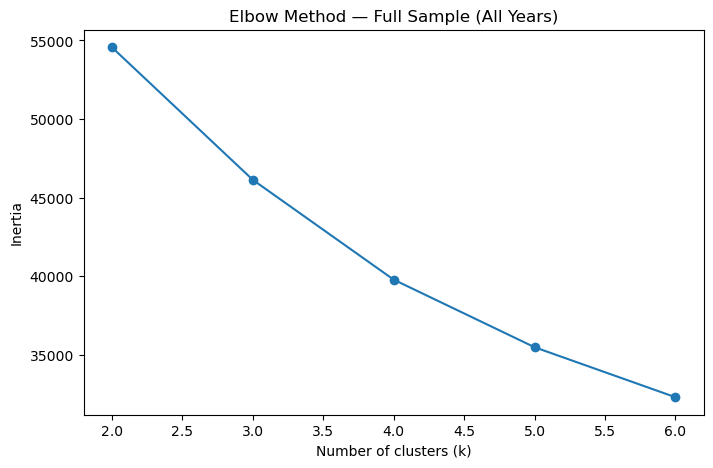

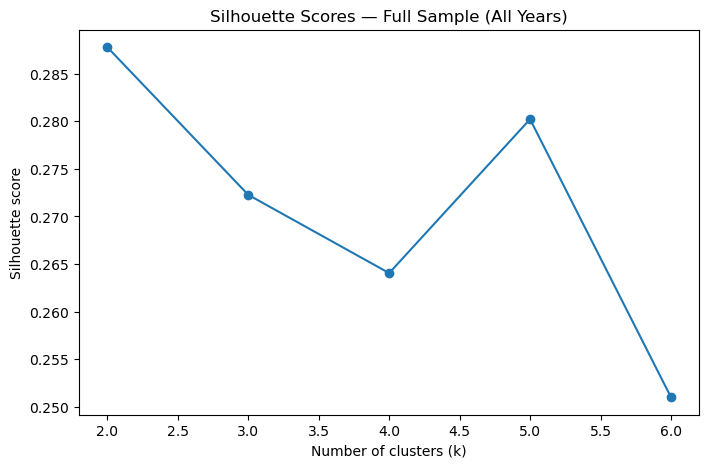

Elbow computation time (s): 9.7230
Clustering time (s): 0.6866
Silhouette score (k=3): 0.272

Cluster sizes:
cluster
0    6810
1    4053
2    1790
Name: count, dtype: int64

Cluster Centers (Standardized):
            SIZE  KOSPI   big4   forn    own    AGE
Cluster 0 -0.547 -0.859 -0.350 -0.335 -0.149 -0.350
Cluster 1  0.289  1.083  0.197 -0.257  0.416  0.551
Cluster 2  1.428  0.814  0.885  1.859 -0.376  0.085


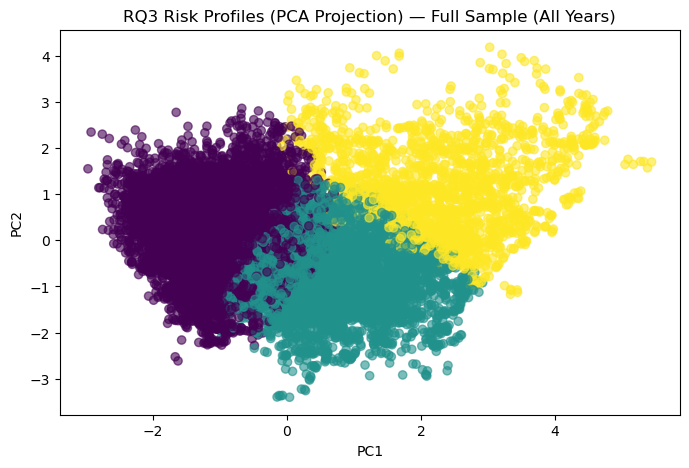

PCA computation time (s): 0.0128

Average Single-Year Tax Outcomes by Risk Profile:
          CETR   GETR   TSTA   TSDA  n_obs
cluster                                   
0        0.228  0.185 -0.156 -0.169   6810
1        0.260  0.217 -0.006 -0.008   4053
2        0.270  0.231  0.010  0.003   1790

Average Persistent Tax Outcomes (Validation):
         CETR3  GETR3  CETR5  GETR5   TSTA   TSDA  n_obs
cluster                                                 
0        0.201  0.185  0.185  0.183 -0.156 -0.169   6810
1        0.237  0.218  0.218  0.217 -0.006 -0.008   4053
2        0.238  0.230  0.217  0.226  0.010  0.003   1790
Total memory increase (MB): 24.37

RQ3 Risk Profiling — Pre‑COVID (≤2019)
Observations used for clustering: 7514
Number of features used: 6
Scaling time (s): 0.0066
Memory increase after scaling (MB): 0.05


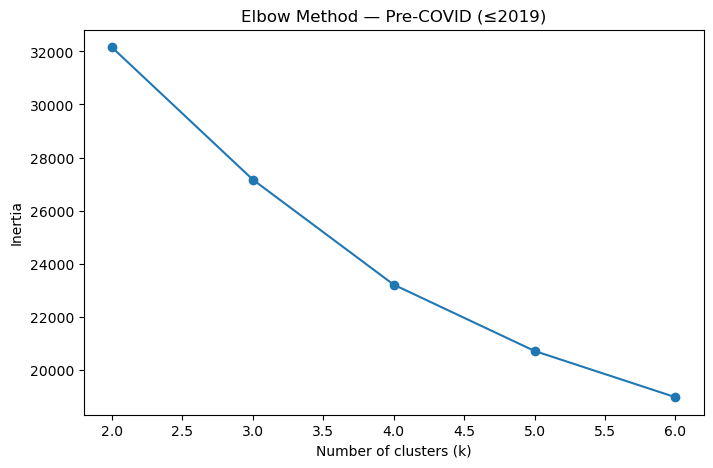

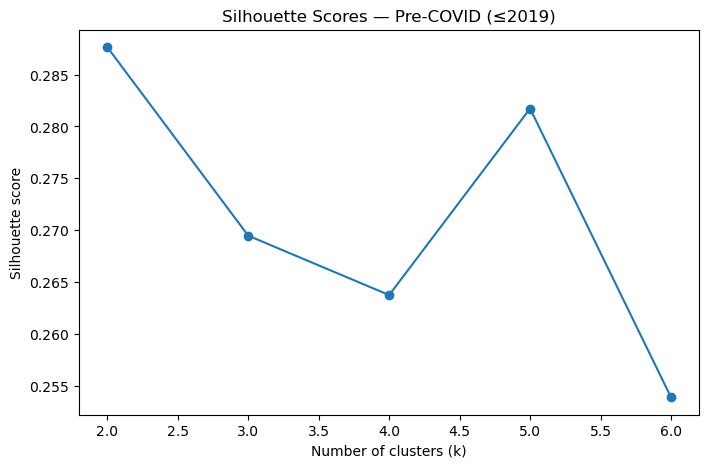

Elbow computation time (s): 6.5690
Clustering time (s): 0.7254
Silhouette score (k=3): 0.269

Cluster sizes:
cluster
0    3959
1    2459
2    1096
Name: count, dtype: int64

Cluster Centers (Standardized):
            SIZE  KOSPI   big4   forn    own    AGE
Cluster 0 -0.565 -0.879 -0.343 -0.350 -0.160 -0.392
Cluster 1  0.268  1.056  0.188 -0.258  0.410  0.549
Cluster 2  1.441  0.805  0.818  1.843 -0.344  0.183


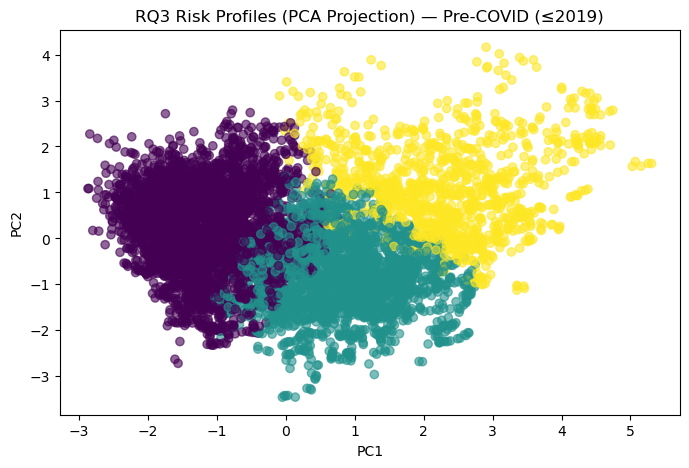

PCA computation time (s): 0.0058

Average Single-Year Tax Outcomes by Risk Profile:
          CETR   GETR   TSTA   TSDA  n_obs
cluster                                   
0        0.236  0.190 -0.035 -0.049   3959
1        0.277  0.228  0.029  0.026   2459
2        0.278  0.241  0.007 -0.000   1096

Average Persistent Tax Outcomes (Validation):
         CETR3  GETR3  CETR5  GETR5   TSTA   TSDA  n_obs
cluster                                                 
0        0.195  0.184  0.178  0.184 -0.035 -0.049   3959
1        0.236  0.219  0.210  0.219  0.029  0.026   2459
2        0.232  0.227  0.206  0.223  0.007 -0.000   1096
Total memory increase (MB): 4.23

RQ3 Risk Profiling — Post‑COVID (≥2020)
Observations used for clustering: 5139
Number of features used: 6
Scaling time (s): 0.0024
Memory increase after scaling (MB): 0.00


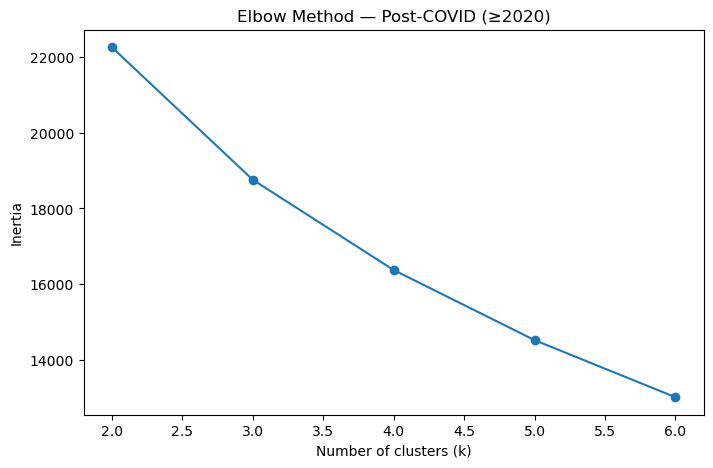

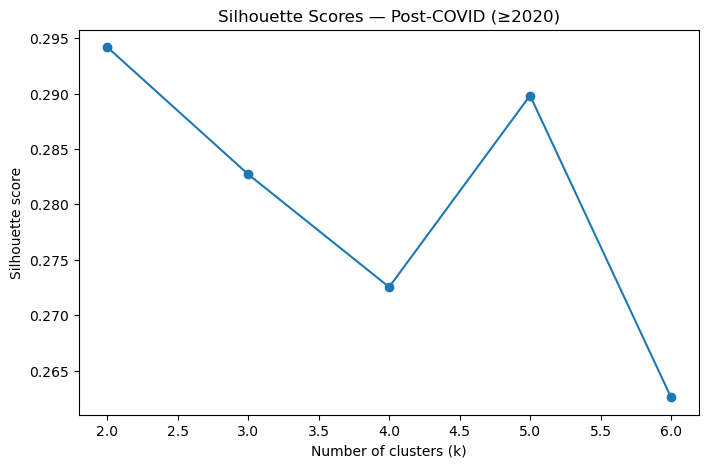

Elbow computation time (s): 5.1769
Clustering time (s): 0.6819
Silhouette score (k=3): 0.283

Cluster sizes:
cluster
0    2873
1    1564
2     702
Name: count, dtype: int64

Cluster Centers (Standardized):
            SIZE  KOSPI   big4   forn    own    AGE
Cluster 0 -0.531 -0.830 -0.351 -0.310 -0.122 -0.296
Cluster 1  0.315  1.154  0.176 -0.245  0.392  0.596
Cluster 2  1.470  0.823  1.046  1.816 -0.374 -0.118


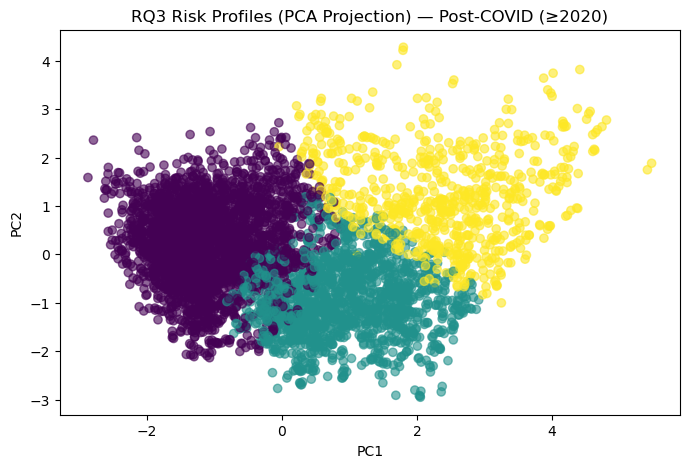

PCA computation time (s): 0.0071

Average Single-Year Tax Outcomes by Risk Profile:
          CETR   GETR   TSTA   TSDA  n_obs
cluster                                   
0        0.216  0.178 -0.323 -0.333   2873
1        0.235  0.200 -0.061 -0.061   1564
2        0.256  0.216  0.016  0.010    702

Average Persistent Tax Outcomes (Validation):
         CETR3  GETR3  CETR5  GETR5   TSTA   TSDA  n_obs
cluster                                                 
0        0.210  0.186  0.195  0.182 -0.323 -0.333   2873
1        0.241  0.217  0.231  0.216 -0.061 -0.061   1564
2        0.249  0.235  0.236  0.229  0.016  0.010    702
Total memory increase (MB): 0.12


In [10]:


process = psutil.Process(os.getpid())

# -----------------------
# RQ3: Risk Profiling
# -----------------------

profile_vars = [
    'SIZE','KOSPI','big4','forn','own','AGE'
]

# =======================
# Define subsamples
# =======================
samples = {
    'Full Sample (All Years)': df,
    'Pre‑COVID (≤2019)': df[df['year'] <= 2019],
    'Post‑COVID (≥2020)': df[df['year'] >= 2020]
}

# =====================================================
# Loop over samples
# =====================================================
for sample_name, df_sub in samples.items():

    print("\n" + "="*80)
    print(f"RQ3 Risk Profiling — {sample_name}")
    print("="*80)

    X = df_sub[profile_vars].dropna()
    print("Observations used for clustering:", X.shape[0])
    print("Number of features used:", len(profile_vars))

    # -----------------------
    # Scaling (efficiency)
    # -----------------------
    mem_before = process.memory_info().rss / 1024**2  # MB
    start_scale = time.time()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    scale_time = time.time() - start_scale
    mem_after_scale = process.memory_info().rss / 1024**2

    print(f"Scaling time (s): {scale_time:.4f}")
    print(f"Memory increase after scaling (MB): {mem_after_scale - mem_before:.2f}")

    # ------------------------------------------------
    # Option B: Elbow + silhouette across k
    # ------------------------------------------------
    inertia = []
    silhouette_vals = []

    start_elbow = time.time()
    for k in range(2, 7):
        km_tmp = KMeans(n_clusters=k, random_state=0, n_init=20)
        labels_tmp = km_tmp.fit_predict(X_scaled)

        inertia.append(km_tmp.inertia_)
        silhouette_vals.append(silhouette_score(X_scaled, labels_tmp))

    elbow_time = time.time() - start_elbow

    # Elbow plot
    plt.figure(figsize=(8,5))
    plt.plot(range(2,7), inertia, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method — {sample_name}")
    plt.show()

    # Silhouette plot
    plt.figure(figsize=(8,5))
    plt.plot(range(2,7), silhouette_vals, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title(f"Silhouette Scores — {sample_name}")
    plt.show()

    print(f"Elbow computation time (s): {elbow_time:.4f}")

    # -----------------------
    # Final KMeans clustering (k=3)
    # -----------------------
    start_cluster = time.time()

    km = KMeans(n_clusters=3, random_state=0, n_init=20)
    clusters = km.fit_predict(X_scaled)

    cluster_time = time.time() - start_cluster

    print(f"Clustering time (s): {cluster_time:.4f}")

    # ------------------------------------------------
    # Option A: Silhouette for final model
    # ------------------------------------------------
    sil_final = silhouette_score(X_scaled, clusters)
    print(f"Silhouette score (k=3): {sil_final:.3f}")

    # Attach clusters
    df_rq3 = df_sub.loc[X.index].copy()
    df_rq3['cluster'] = clusters

    print("\nCluster sizes:")
    print(df_rq3['cluster'].value_counts().sort_index())

    # -----------------------
    # Cluster centers
    # -----------------------
    centers_df = pd.DataFrame(
        km.cluster_centers_,
        columns=profile_vars,
        index=[f'Cluster {i}' for i in range(km.n_clusters)]
    )

    print("\nCluster Centers (Standardized):")
    print(centers_df.round(3))

    # -----------------------
    # PCA (visualization)
    # -----------------------
    start_pca = time.time()
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    pca_time = time.time() - start_pca

    plt.figure(figsize=(8,5))
    plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=clusters,
        cmap='viridis',
        alpha=0.6
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"RQ3 Risk Profiles (PCA Projection) — {sample_name}")
    plt.show()

    print(f"PCA computation time (s): {pca_time:.4f}")

    # -----------------------
    # Tax outcomes (single-year)
    # -----------------------
    tax_summary = (
        df_rq3
        .groupby('cluster')[['CETR','GETR','TSTA','TSDA']]
        .mean()
    )

    tax_summary['n_obs'] = df_rq3['cluster'].value_counts().sort_index()

    print("\nAverage Single-Year Tax Outcomes by Risk Profile:")
    print(tax_summary.round(3))

    # -----------------------
    # Persistent tax behavior (validation)
    # -----------------------
    validation_vars = ['CETR3','GETR3','CETR5','GETR5','TSTA','TSDA']

    validation_summary = (
        df_rq3
        .groupby('cluster')[validation_vars]
        .mean()
    )

    validation_summary['n_obs'] = df_rq3['cluster'].value_counts().sort_index()

    print("\nAverage Persistent Tax Outcomes (Validation):")
    print(validation_summary.round(3))

    # -----------------------
    # Final memory usage
    # -----------------------
    mem_final = process.memory_info().rss / 1024**2
    print(f"Total memory increase (MB): {mem_final - mem_before:.2f}")
